In [1]:
# Cell 1: Import all required libraries and dependencies
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq
import os

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Cell 2: Load trajectories and setup data processing
filename = 'Car_trajectories_dataset.npy'
assert os.path.exists(filename), f"{filename} not found!"

trajectories = np.load(filename, allow_pickle=True)
print(f"Loaded {len(trajectories)} trajectories from '{filename}'")
print("Example traj keys:", trajectories[0].keys())
print("states.shape =", trajectories[0]['states'].shape,
      "controls.shape =", trajectories[0]['controls'].shape)

# Setup scalers
class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

# Compute data ranges for normalization
all_states = np.vstack([traj['states'][:, :3] for traj in trajectories])  # Only x,y,theta
all_controls = np.vstack([traj['controls'][:100] for traj in trajectories])  # Only first 99 + padded

state_min, state_max = all_states.min(axis=0), all_states.max(axis=0)  # (3,)
ctrl_min, ctrl_max = all_controls.min(axis=0), all_controls.max(axis=0)  # (2,)

state_scaler = Scaler(state_min, state_max)
control_scaler = Scaler(ctrl_min, ctrl_max)

print(f"State ranges: {state_min} to {state_max}")
print(f"Control ranges: {ctrl_min} to {ctrl_max}")


Loaded 1000 trajectories from 'Car_trajectories_dataset.npy'
Example traj keys: dict_keys(['states', 'controls', 'start', 'target'])
states.shape = (100, 5) controls.shape = (100, 2)
State ranges: [-1.19790784 -1.19865137  0.        ] to [1.20161734 1.19020141 1.22612348]
Control ranges: [-0.13367486 -0.18193647] to [0.1368776 0.2      ]


In [3]:
# Cell 3: Create single-step dataset
class SingleStepDataset(Dataset):
    def __init__(self, trajectories, state_scaler, control_scaler):
        self.state_scaler = state_scaler
        self.control_scaler = control_scaler
        self.data_pairs = []
        
        print("Processing trajectories into single-step pairs...")
        for traj_idx, traj in enumerate(trajectories):
            states = traj['states'][:, :3]  # (100, 3) [x, y, theta]
            controls = traj['controls'][:100, :]  # (100, 2) [accel, steer]
            
            # Generate pairs for steps 0 to 98 (99 pairs)
            for t in range(99):
                current_state = states[t]  # (3,) state at time t
                current_control = controls[t]  # (2,) control at time t
                next_state = states[t+1]  # (3,) state at time t+1
                
                # Target: [control_t, state_t+1] = (5,)
                target = np.concatenate([current_control, next_state])
                self.data_pairs.append((current_state, target))
            
            # Special case: step 99 -> step 100 (repeat state, zero control)
            current_state = states[99]  # (3,) state at time 99
            repeated_state = states[99]  # repeat last state
            zero_control = np.zeros(2)  # zero control
            target = np.concatenate([zero_control, repeated_state])
            self.data_pairs.append((current_state, target))
        
        print(f"Created {len(self.data_pairs)} single-step pairs")
        print(f"Expected: {len(trajectories) * 100} pairs")
    
    def __len__(self):
        return len(self.data_pairs)
    
    def __getitem__(self, idx):
        current_state, target = self.data_pairs[idx]
        
        # Normalize inputs
        current_state_norm = self.state_scaler.normalize(current_state)  # (3,)
        
        # Split and normalize target
        control_part = target[:2]  # (2,)
        state_part = target[2:]    # (3,)
        control_norm = self.control_scaler.normalize(control_part)
        state_norm = self.state_scaler.normalize(state_part)
        target_norm = np.concatenate([control_norm, state_norm])  # (5,)
        
        return (
            torch.from_numpy(current_state_norm.astype(np.float32)),
            torch.from_numpy(target_norm.astype(np.float32))
        )

# Create dataset and dataloader
batch_size = 512
train_dataset = SingleStepDataset(trajectories, state_scaler, control_scaler)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"Train loader ready, #batches = {len(train_loader)}")


Processing trajectories into single-step pairs...
Created 100000 single-step pairs
Expected: 100000 pairs
Train loader ready, #batches = 196


Sample condition shape: torch.Size([3])
Sample target shape: torch.Size([5])
Condition (normalized): [-0.9720141 -0.9201941 -1.       ]
Target (normalized): [ 0.5476351  1.        -0.9720141 -0.9201941 -1.       ]

Denormalized condition [x,y,theta]: [-1.16433144 -1.10332909  0.        ]
Denormalized target control [a,delta]: [0.07568338 0.2       ]
Denormalized target state [x,y,theta]: [-1.16433144 -1.10332909  0.        ]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


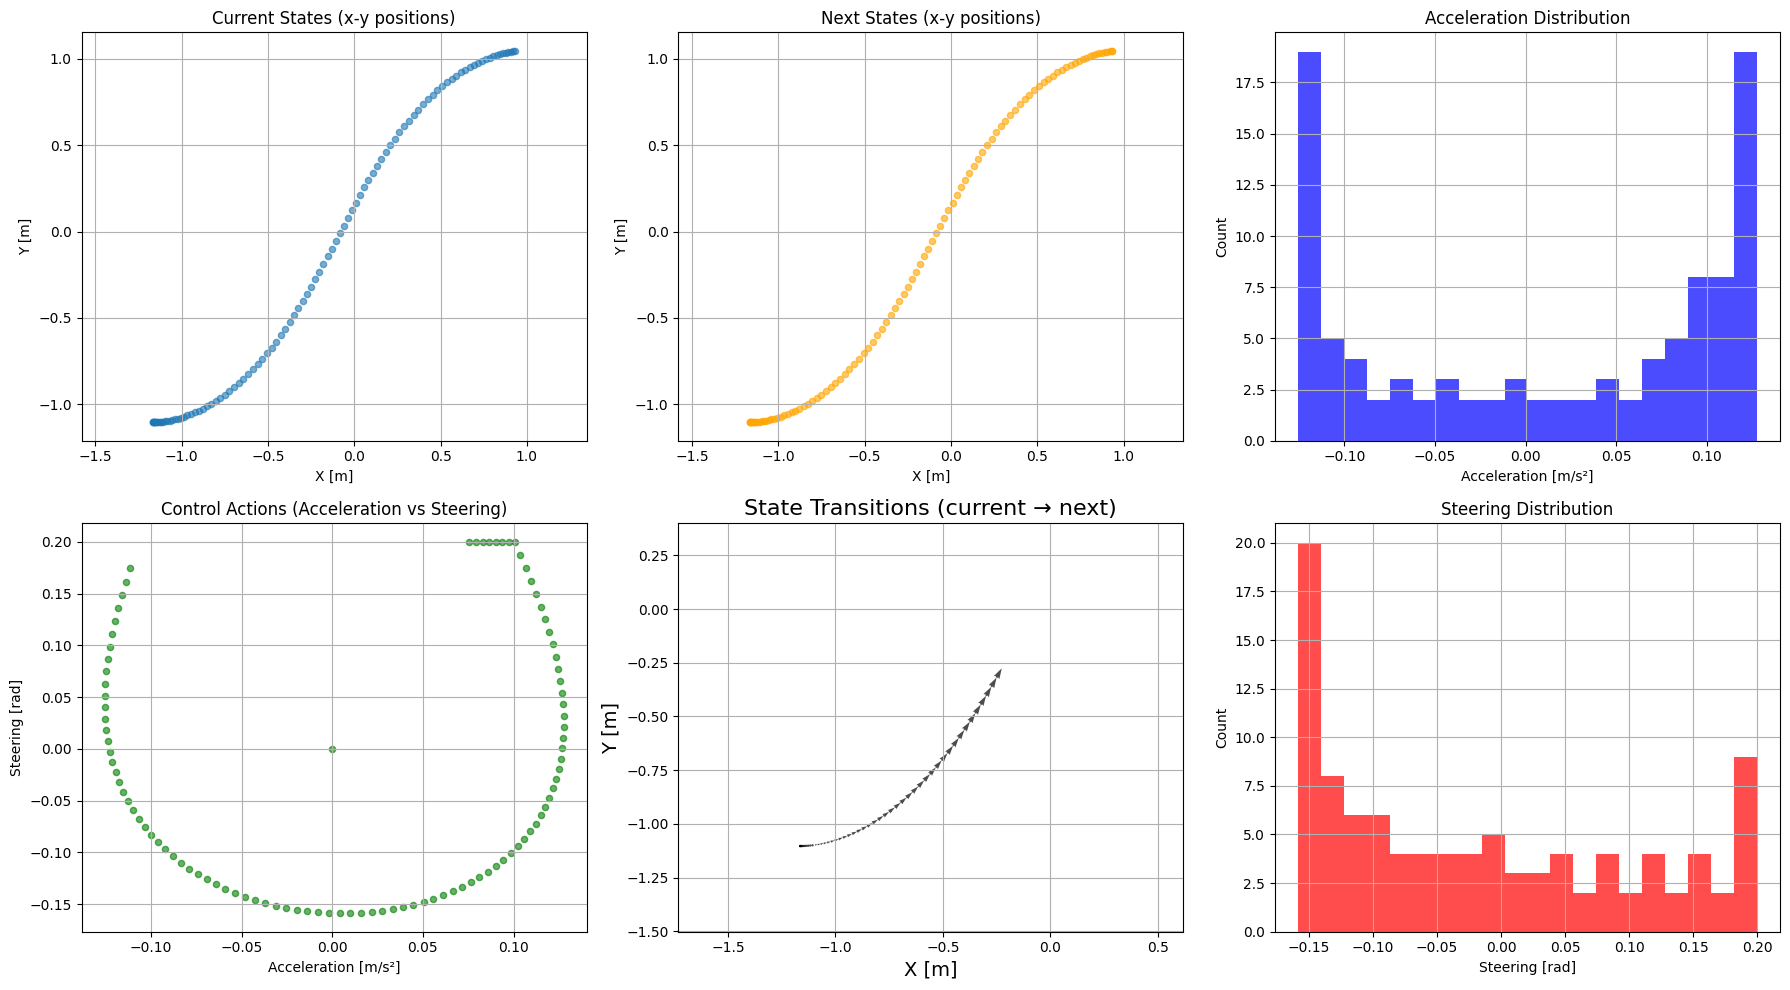


Dataset verification complete!
Control range: accel [-0.126, 0.128], steer [-0.159, 0.200]


In [4]:
# Cell 4: Visualize dataset samples
# Sample a few data points to verify
sample_condition, sample_target = train_dataset[0]
print(f"Sample condition shape: {sample_condition.shape}")
print(f"Sample target shape: {sample_target.shape}")
print(f"Condition (normalized): {sample_condition.numpy()}")
print(f"Target (normalized): {sample_target.numpy()}")

# Denormalize to check
condition_denorm = state_scaler.denormalize(sample_condition.numpy())
target_denorm_ctrl = control_scaler.denormalize(sample_target.numpy()[:2])
target_denorm_state = state_scaler.denormalize(sample_target.numpy()[2:])

print(f"\nDenormalized condition [x,y,theta]: {condition_denorm}")
print(f"Denormalized target control [a,delta]: {target_denorm_ctrl}")
print(f"Denormalized target state [x,y,theta]: {target_denorm_state}")

# Visualize multiple samples
num_samples = 100
conditions = []
targets = []

for i in range(min(num_samples, len(train_dataset))):
    cond, targ = train_dataset[i]
    conditions.append(state_scaler.denormalize(cond.numpy()))
    targets.append({
        'control': control_scaler.denormalize(targ.numpy()[:2]),
        'next_state': state_scaler.denormalize(targ.numpy()[2:])
    })

conditions = np.array(conditions)
controls = np.array([t['control'] for t in targets])
next_states = np.array([t['next_state'] for t in targets])

# Plot visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Current states scatter
axes[0,0].scatter(conditions[:, 0], conditions[:, 1], alpha=0.6, s=20)
axes[0,0].set_title('Current States (x-y positions)')
axes[0,0].set_xlabel('X [m]')
axes[0,0].set_ylabel('Y [m]')
axes[0,0].grid(True)
axes[0,0].axis('equal')

# Next states scatter
axes[0,1].scatter(next_states[:, 0], next_states[:, 1], alpha=0.6, s=20, color='orange')
axes[0,1].set_title('Next States (x-y positions)')
axes[0,1].set_xlabel('X [m]')
axes[0,1].set_ylabel('Y [m]')
axes[0,1].grid(True)
axes[0,1].axis('equal')

# Control distribution (acceleration vs steering)
axes[1,0].scatter(controls[:, 0], controls[:, 1], alpha=0.6, s=20, color='green')
axes[1,0].set_title('Control Actions (Acceleration vs Steering)')
axes[1,0].set_xlabel('Acceleration [m/s²]')
axes[1,0].set_ylabel('Steering [rad]')
axes[1,0].grid(True)

# State transitions (arrows)
axes[1,1].quiver(conditions[:50, 0], conditions[:50, 1], 
                 next_states[:50, 0] - conditions[:50, 0], 
                 next_states[:50, 1] - conditions[:50, 1],
                 alpha=0.7, scale_units='xy', scale=1, width=0.005)
axes[1,1].set_title('State Transitions (current → next)', fontsize=16)
axes[1,1].set_xlabel('X [m]', fontsize=14)
axes[1,1].set_ylabel('Y [m]', fontsize=14)
axes[1,1].grid(True)
axes[1,1].axis('equal')

# Acceleration distribution (histogram)
axes[0,2].hist(controls[:, 0], bins=20, color='blue', alpha=0.7)
axes[0,2].set_title('Acceleration Distribution')
axes[0,2].set_xlabel('Acceleration [m/s²]')
axes[0,2].set_ylabel('Count')
axes[0,2].grid(True)

# Steering distribution (histogram)
axes[1,2].hist(controls[:, 1], bins=20, color='red', alpha=0.7)
axes[1,2].set_title('Steering Distribution')
axes[1,2].set_xlabel('Steering [rad]')
axes[1,2].set_ylabel('Count')
axes[1,2].grid(True)

# Adjust axis limits for state transitions to show all data
x_min = min(conditions[:50, 0].min(), next_states[:50, 0].min()) - 1
x_max = max(conditions[:50, 0].max(), next_states[:50, 0].max()) + 1
y_min = min(conditions[:50, 1].min(), next_states[:50, 1].min()) - 1
y_max = max(conditions[:50, 1].max(), next_states[:50, 1].max()) + 1
axes[1,1].set_xlim(x_min*0.8, x_max*0.8)
axes[1,1].set_ylim(y_min*0.8, y_max*0.8)

plt.tight_layout()
plt.show()


print(f"\nDataset verification complete!")
print(f"Control range: accel [{controls[:,0].min():.3f}, {controls[:,0].max():.3f}], steer [{controls[:,1].min():.3f}, {controls[:,1].max():.3f}]")



Random sample index: 80473
Condition (normalized): [0.37378687 0.5794255  0.44315162]
Target (normalized): [-0.7516777  -0.5452296   0.39659697  0.60741043  0.40021503]
Condition (denormalized) [x, y, theta]: [0.45031032 0.68785622 0.88474103]
Target control (denormalized) [a, delta]: [-0.10008275 -0.09508977]
Target next state (denormalized) [x, y, theta]: [0.47767689 0.72128207 0.85841826]


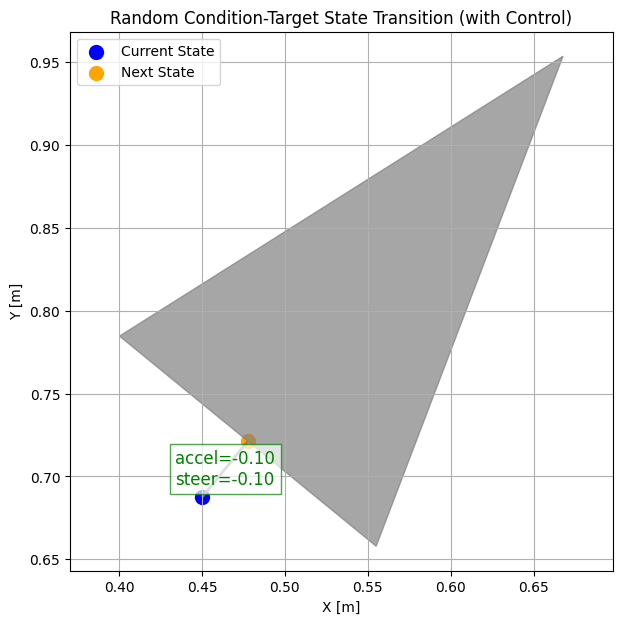

In [5]:

# Plot a random picked condition-target pair and control value
import random
rand_idx = random.randint(0, len(train_dataset)-1)
rand_condition, rand_target = train_dataset[rand_idx]
rand_condition_denorm = state_scaler.denormalize(rand_condition.numpy())
rand_target_ctrl_denorm = control_scaler.denormalize(rand_target.numpy()[:2])
rand_target_state_denorm = state_scaler.denormalize(rand_target.numpy()[2:])

print("\nRandom sample index:", rand_idx)
print("Condition (normalized):", rand_condition.numpy())
print("Target (normalized):", rand_target.numpy())
print("Condition (denormalized) [x, y, theta]:", rand_condition_denorm)
print("Target control (denormalized) [a, delta]:", rand_target_ctrl_denorm)
print("Target next state (denormalized) [x, y, theta]:", rand_target_state_denorm)

# Plot the current and next state for the random sample, and show control value
plt.figure(figsize=(7,7))
plt.scatter(rand_condition_denorm[0], rand_condition_denorm[1], color='blue', label='Current State', s=100)
plt.scatter(rand_target_state_denorm[0], rand_target_state_denorm[1], color='orange', label='Next State', s=100)
plt.arrow(rand_condition_denorm[0], rand_condition_denorm[1],
          rand_target_state_denorm[0] - rand_condition_denorm[0],
          rand_target_state_denorm[1] - rand_condition_denorm[1],
          head_width=0.2, head_length=0.3, fc='gray', ec='gray', alpha=0.7)

# Annotate control value at the midpoint of the arrow
mid_x = (rand_condition_denorm[0] + rand_target_state_denorm[0]) / 2
mid_y = (rand_condition_denorm[1] + rand_target_state_denorm[1]) / 2
ctrl_text = f"accel={rand_target_ctrl_denorm[0]:.2f}\nsteer={rand_target_ctrl_denorm[1]:.2f}"
plt.text(mid_x, mid_y, ctrl_text, fontsize=12, color='green', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='green'))

plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Random Condition-Target State Transition (with Control)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [6]:
# Cell 7: Direct Input + Time Embedding + Multi-Head Attention Flow Model
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return self.act(out + x)
    
class UNetSmall(UNetModel):
    def __init__(self, dim=(1, 8, 8), num_channels=32, num_res_blocks=1, num_classes=10):
        super().__init__(
            image_size=dim[-1],
            in_channels=dim[0],
            model_channels=num_channels,
            out_channels=dim[0],
            num_res_blocks=num_res_blocks,
            attention_resolutions=(4,),  # Attention at 4x4
            channel_mult=(1, 2),
            num_classes=num_classes
        )
# Smaller upsampler for 5D input/output
class StepUpsampler(nn.Module):
    def __init__(self, input_dim=5, output_shape=(1, 8, 8), width=512, depth=4):
        super().__init__()
        out_dim = np.prod(output_shape)
        layers = [nn.Linear(input_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.output_shape = output_shape
    
    def forward(self, x):
        # x: (batch_size, 5)
        x = self.net(x)  # (batch_size, 64)
        x = self.norm(x)
        return x.view(x.size(0), *self.output_shape)  # (batch_size, 1, 8, 8)

class StepDownsampler(nn.Module):
    def __init__(self, input_shape=(1, 8, 8), output_dim=5, width=512, depth=4):
        super().__init__()
        in_dim = np.prod(input_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, output_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        # x: (batch_size, 1, 8, 8)
        x = x.flatten(1)  # (batch_size, 64)
        return self.net(x)  # (batch_size, 5)

class MHSEChannelAttention(nn.Module):
    """
    Multi‑Head Squeeze‑Excitation 通道注意力
    将 C 个通道分成 H 个头，每个头上分别做 SE，最后拼回或平均。
    """
    def __init__(self, channels, reduction=16, heads=4, fuse='concat'):
        """
        channels: 输入通道数 C
        reduction: 每个 head 内部的降维比例
        heads: 头数 H
        fuse: 'concat' 或 'mean'
          - 'concat'：对每个 head 的输出做 concat → 再降维回 C
          - 'mean'：对 H 个 head 的权重做 mean → 统一应用
        """
        super().__init__()
        assert channels % heads == 0, "channels 必须被 heads 整除"
        self.channels = channels
        self.heads = heads
        self.fuse = fuse
        
        self.subc = channels // heads
        # 每个 head 的 SE MLP
        self.se_blocks = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Linear(self.subc, self.subc // reduction, bias=False),
                nn.ReLU(inplace=True),
                nn.Linear(self.subc // reduction, self.subc, bias=False),
                nn.Sigmoid()
            )
            for _ in range(heads)
        ])
        if fuse == 'concat':
            # 拼回后需要一个 1×1 卷积或 FC 把 H*subc 再映射回 C
            self.fuse_conv = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
    
    def forward(self, x):
        B, C, H, W = x.shape
        # 按头拆分
        xs = x.view(B, self.heads, self.subc, H, W)  # B×H×subc×H×W
        weights = []
        for i, se in enumerate(self.se_blocks):
            # 对第 i 个 head 做 GAP + MLP → 得到 subc 个权重
            w = se(xs[:, i])             # B×subc
            weights.append(w)
        # fuse 权重
        if self.fuse == 'mean':
            # 直接平均每个 head 的权重
            w = torch.stack(weights, dim=0).mean(0)     # B×subc
            w = w.view(B, self.subc, 1, 1)
            # 重标定，然后恢复原 shape
            out = xs * w.unsqueeze(1)                   # B×H×subc×H×W
            return out.view(B, C, H, W)
        else:  # 'concat'
            # 将每个 head 的加权结果拼回
            out_heads = []
            for i, w in enumerate(weights):
                w = w.view(B, self.subc, 1, 1)
                out_heads.append(xs[:, i] * w)
            out = torch.cat(out_heads, dim=1)           # B×C×H×W
            return self.fuse_conv(out)                 # 1×1 卷积融合

class CBAMWithMHSE(nn.Module):
    """CBAM with Multi-Head SE Channel Attention"""
    def __init__(self, channels, reduction=16, heads=4, kernel_size=7):
        super().__init__()
        self.ca = MHSEChannelAttention(channels, reduction, heads, fuse='concat')
        # 空间注意力和之前一样
        padding = (kernel_size - 1) // 2
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.ca(x)
        # CBAM 空间分支
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = x * self.sa(torch.cat([avg_out, max_out], dim=1))
        return x

class EnhancedStepUpsampler(nn.Module):
    """Enhanced upsampler with direct condition input and attention"""
    def __init__(self, input_dim=8, output_shape=(1, 8, 8), width=512, depth=4, attention_heads=4):
        super().__init__()
        out_dim = np.prod(output_shape)
        
        # 输入处理层
        layers = [nn.Linear(input_dim, width), Mish()]
        
        # 残差块
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        
        # 输出层
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.output_shape = output_shape
        
        # 添加注意力机制到输出特征图
        self.attention = CBAMWithMHSE(
            channels=output_shape[0], 
            reduction=16, 
            heads=min(attention_heads, output_shape[0]),
            kernel_size=3
        )
    
    def forward(self, x):
        # x: (batch_size, 8) - [control(2) + next_state(3) + current_state(3)]
        x = self.net(x)  # (batch_size, 64)
        x = self.norm(x)
        x = x.view(x.size(0), *self.output_shape)  # (batch_size, 1, 8, 8)
        
        # 应用注意力机制
        x = self.attention(x)
        
        return x

class DirectConditionalStepFlowModel(ModelWrapper):
    """
    Direct Input + Time Embedding + Multi-Head Attention Flow Model
    最优方案：直接输入条件 + 时间嵌入 + 多头注意力
    """
    def __init__(self, unet_model, downsampler, condition_dim=3, time_embed_dim=256):
        nn.Module.__init__(self)  # Direct initialization
        self.unet = unet_model
        self.downsampler = downsampler
        self.condition_dim = condition_dim
        self.time_embed_dim = time_embed_dim
        
        # 增强的upsampler：直接接受 (5 + 3) = 8维输入
        self.upsampler = EnhancedStepUpsampler(
            input_dim=5 + condition_dim,  # 8维：[control(2) + next_state(3) + current_state(3)]
            output_shape=(1, 8, 8), 
            width=512, 
            depth=4,
            attention_heads=4
        )
        
        # 时间嵌入网络
        self.time_embed = nn.Sequential(
            nn.Linear(time_embed_dim, 512),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.SiLU(),
            nn.Linear(256, 64)  # 匹配特征图空间维度 8*8=64
        )
        
        # 条件-时间融合注意力
        self.condition_time_attention = nn.MultiheadAttention(
            embed_dim=64,  # 特征图展平后的维度
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # 融合后的特征重塑
        self.feature_reshape = nn.Sequential(
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )
        
        print("Direct Conditional Step Flow Model initialized:")
        print(f"  - Input dimension: {5 + condition_dim} (direct condition integration)")
        print(f"  - Time embedding dimension: {time_embed_dim}")
        print(f"  - Multi-head attention: 8 heads")
        print(f"  - CBAM with Multi-Head SE attention in upsampler")
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, condition: torch.Tensor = None, **extras):
        """
        Enhanced forward pass with direct condition + time embedding + attention
        
        Args:
            x: noise input (batch_size, 5) [control(2) + next_state(3)]
            t: time (batch_size,)
            condition: current state (batch_size, 3) [x, y, theta] - 保持原始精度
        """
        batch_size = x.shape[0]
        
        # 1. 直接条件输入融合
        if condition is not None:
            # 直接拼接：完全保持条件信息精度
            x_conditioned = torch.cat([x, condition], dim=1)  # (batch_size, 8)
        else:
            # 无条件情况
            zero_condition = torch.zeros(batch_size, self.condition_dim, device=x.device)
            x_conditioned = torch.cat([x, zero_condition], dim=1)
        
        # 2. 上采样到特征图空间（含多头注意力）
        x_img = self.upsampler(x_conditioned)  # (batch_size, 1, 8, 8)
        
        # 3. 时间嵌入
        time_emb = self._get_time_embedding(t, self.time_embed_dim)  # (batch_size, time_embed_dim)
        time_features = self.time_embed(time_emb)  # (batch_size, 64)
        
        # 4. 条件-时间注意力融合
        # 将特征图展平用于注意力计算
        x_flat = x_img.view(batch_size, -1)  # (batch_size, 64)
        
        # 多头注意力：特征图作为query，时间嵌入作为key和value
        attended_features, _ = self.condition_time_attention(
            query=x_flat.unsqueeze(1),      # (batch_size, 1, 64)
            key=time_features.unsqueeze(1),    # (batch_size, 1, 64)
            value=time_features.unsqueeze(1)   # (batch_size, 1, 64)
        )
        attended_features = attended_features.squeeze(1)  # (batch_size, 64)
        
        # 5. 融合原始特征和注意力特征
        fused_features = x_flat + attended_features  # 残差连接
        fused_features = self.feature_reshape(fused_features)  # (batch_size, 64)
        
        # 6. 重塑回特征图
        enhanced_x_img = fused_features.view(batch_size, 1, 8, 8)  # (batch_size, 1, 8, 8)
        
        # 7. 通过UNet
        dummy_labels = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        v_img = self.unet(t, enhanced_x_img, y=dummy_labels)
        
        # 8. 下采样回动作空间
        v_output = self.downsampler(v_img)  # (batch_size, 5)
        
        return v_output
    
    def _get_time_embedding(self, timesteps, embedding_dim):
        """
        创建正弦-余弦时间嵌入
        """
        half_dim = embedding_dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
        emb = timesteps[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        
        if embedding_dim % 2 == 1:  # 如果是奇数维度
            emb = torch.cat([emb, torch.zeros(emb.shape[0], 1, device=emb.device)], dim=1)
        
        return emb

# 对应的初始化代码修改
print("Direct Conditional Step Flow Model with Multi-Head Attention defined!")
print("Features:")
print("  ✅ Direct condition input (no information loss)")
print("  ✅ Sinusoidal time embedding")
print("  ✅ Multi-head self-attention for condition-time fusion")
print("  ✅ CBAM with Multi-Head SE channel attention")
print("  ✅ Residual connections for stable training")

Direct Conditional Step Flow Model with Multi-Head Attention defined!
Features:
  ✅ Direct condition input (no information loss)
  ✅ Sinusoidal time embedding
  ✅ Multi-head self-attention for condition-time fusion
  ✅ CBAM with Multi-Head SE channel attention
  ✅ Residual connections for stable training


In [7]:
# # Cell 7: Initialize models and training setup
# # Model components
# 将原来的初始化部分：
# upsampler = StepUpsampler().to(device)
# downsampler = StepDownsampler().to(device)
# unet = UNetSmall().to(device)
# flow_model = ConditionalStepFlowModel(upsampler, unet, downsampler).to(device)

# 替换为：
downsampler = StepDownsampler().to(device)
unet = UNetSmall().to(device)
flow_model = DirectConditionalStepFlowModel(
    unet_model=unet, 
    downsampler=downsampler, 
    condition_dim=3,
    time_embed_dim=256
).to(device)

# Training parameters
n_epochs = 2000
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)

# Optimizer
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr)

# Learning rate scheduler
scheduler = LambdaLR(
    optimizer, lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5*(1.0 + math.cos(math.pi*(epoch - warmup_epochs)/(n_epochs - warmup_epochs)))
    )
)

# Flow matching path
path = AffinePath(scheduler=CondOTScheduler())

print(f"Training setup complete. Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")




Direct Conditional Step Flow Model initialized:
  - Input dimension: 8 (direct condition integration)
  - Time embedding dimension: 256
  - Multi-head attention: 8 heads
  - CBAM with Multi-Head SE attention in upsampler


/home/nvidiapc/Flow_ICLR/fmtorch/.venv/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Training setup complete. Device: cuda
Model parameters: 3,131,321


Starting training for 2000 epochs...
Epoch 100/2000 | Loss: 0.048120 | LR: 0.000050
Epoch 200/2000 | Loss: 0.035778 | LR: 0.000100
Epoch 300/2000 | Loss: 0.031175 | LR: 0.000099
Epoch 400/2000 | Loss: 0.028227 | LR: 0.000097
Epoch 500/2000 | Loss: 0.028033 | LR: 0.000093
Epoch 600/2000 | Loss: 0.026731 | LR: 0.000088
Epoch 700/2000 | Loss: 0.026923 | LR: 0.000082
Epoch 800/2000 | Loss: 0.025696 | LR: 0.000075
Epoch 900/2000 | Loss: 0.024220 | LR: 0.000067
Epoch 1000/2000 | Loss: 0.023907 | LR: 0.000059
Epoch 1100/2000 | Loss: 0.024020 | LR: 0.000050
Epoch 1200/2000 | Loss: 0.023631 | LR: 0.000041
Epoch 1300/2000 | Loss: 0.022813 | LR: 0.000033
Epoch 1400/2000 | Loss: 0.022822 | LR: 0.000025
Epoch 1500/2000 | Loss: 0.022204 | LR: 0.000018
Epoch 1600/2000 | Loss: 0.022019 | LR: 0.000012
Epoch 1700/2000 | Loss: 0.021465 | LR: 0.000007
Epoch 1800/2000 | Loss: 0.021235 | LR: 0.000003
Epoch 1900/2000 | Loss: 0.021021 | LR: 0.000001
Epoch 2000/2000 | Loss: 0.020777 | LR: 0.000000
Training com

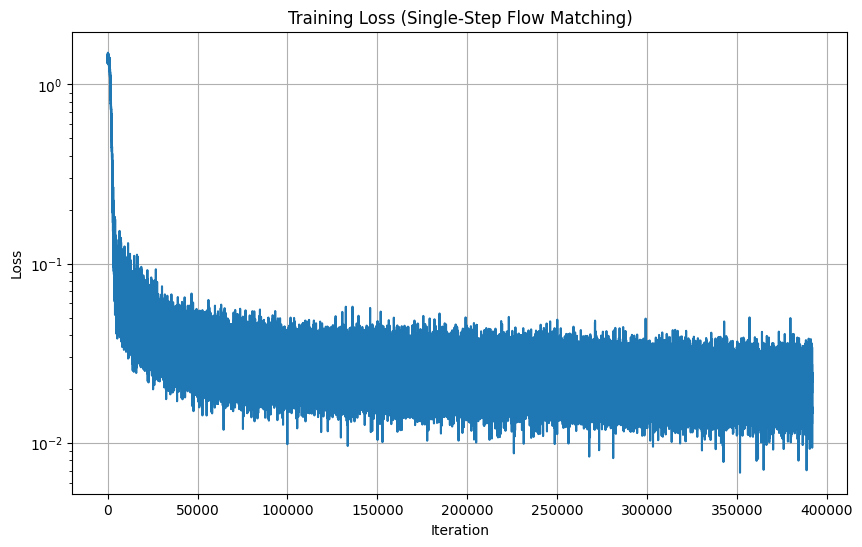

In [8]:
# Cell 8: Training loop
loss_history = []
best_loss = float('inf')
report_interval = max(1, n_epochs // 20)

print(f"Starting training for {n_epochs} epochs...")

for epoch in range(1, n_epochs + 1):
    epoch_loss = 0.0
    batch_count = 0
    
    flow_model.train()
    for batch_conditions, batch_targets in train_loader:
        batch_conditions = batch_conditions.to(device)  # (batch_size, 3)
        batch_targets = batch_targets.to(device)        # (batch_size, 5)
        
        # Flow matching setup
        x0 = torch.randn_like(batch_targets)  # Noise initialization
        x1 = batch_targets                    # Target: [control, next_state]
        t = torch.rand(batch_targets.shape[0]).to(device)
        
        # Sample from probability path
        path_sample = path.sample(t=t, x_0=x0, x_1=x1)
        
        # Predict velocity with condition
        vt_pred = flow_model(path_sample.x_t, path_sample.t, condition=batch_conditions)
        
        # Flow matching loss
        loss = F.mse_loss(vt_pred, path_sample.dx_t)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_count += 1
        loss_history.append(loss.item())
    
    # Update learning rate
    scheduler.step()
    
    # Average loss
    epoch_loss /= batch_count
    
    # Logging
    if epoch % report_interval == 0:
        print(f"Epoch {epoch}/{n_epochs} | Loss: {epoch_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': flow_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
            'state_scaler_min': state_scaler.min,
            'state_scaler_max': state_scaler.max,
            'control_scaler_min': control_scaler.min,
            'control_scaler_max': control_scaler.max,
        }, 'single_step_flow_model_best.pt')

print("Training completed!")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.yscale('log')
plt.grid(True)
plt.title('Training Loss (Single-Step Flow Matching)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()



In [ ]:
# Cell 9: Single-step inference function
def single_step_inference(current_state, flow_model, state_scaler, control_scaler, device):
    """
    Given current state, predict control + next state using Flow Matching
    
    Args:
        current_state: numpy array (3,) [x, y, theta]
        flow_model: trained conditional flow model
        state_scaler, control_scaler: for normalization
    
    Returns:
        predicted_control: numpy array (2,) [accel, steer]
        predicted_next_state: numpy array (3,) [x, y, theta]
    """
    flow_model.eval()
    
    with torch.no_grad():
        # Normalize condition
        current_state_norm = state_scaler.normalize(current_state)
        condition = torch.from_numpy(current_state_norm.astype(np.float32)).unsqueeze(0).to(device)
        
        # Initial noise
        x0 = torch.randn(1, 5, device=device)
        
        # ODE function for flow matching
        def ode_func(t, x_flat):
            x = x_flat.view(1, 5)
            t_tensor = torch.tensor([t], device=device, dtype=torch.float32)
            velocity = flow_model(x, t_tensor, condition=condition)
            return velocity.view(-1)
        
        # Solve ODE from t=0 to t=1
        t_span = torch.tensor([0., 1.], device=device)
        result = torchdiffeq.odeint(
            ode_func,
            x0.view(-1),
            t_span,
            atol=1e-5,
            rtol=1e-5,
            method='dopri5'
        )
        
        # Extract final result
        final_result = result[-1].view(5).cpu().numpy()  # (5,)
        
        # Split and denormalize
        control_norm = final_result[:2]
        next_state_norm = final_result[2:]
        
        predicted_control = control_scaler.denormalize(control_norm)
        predicted_next_state = state_scaler.denormalize(next_state_norm)
        
        return predicted_control, predicted_next_state,

print("Single-step inference function defined.")


Single-step inference function defined.


Loaded best model from epoch 1940 with loss 0.020372
Trajectory 111:
  Mean state error: 0.0021 m
  Mean control error: 0.0077
Trajectory 166:
  Mean state error: 0.0032 m
  Mean control error: 0.0119
Trajectory 799:
  Mean state error: 0.0021 m
  Mean control error: 0.0121


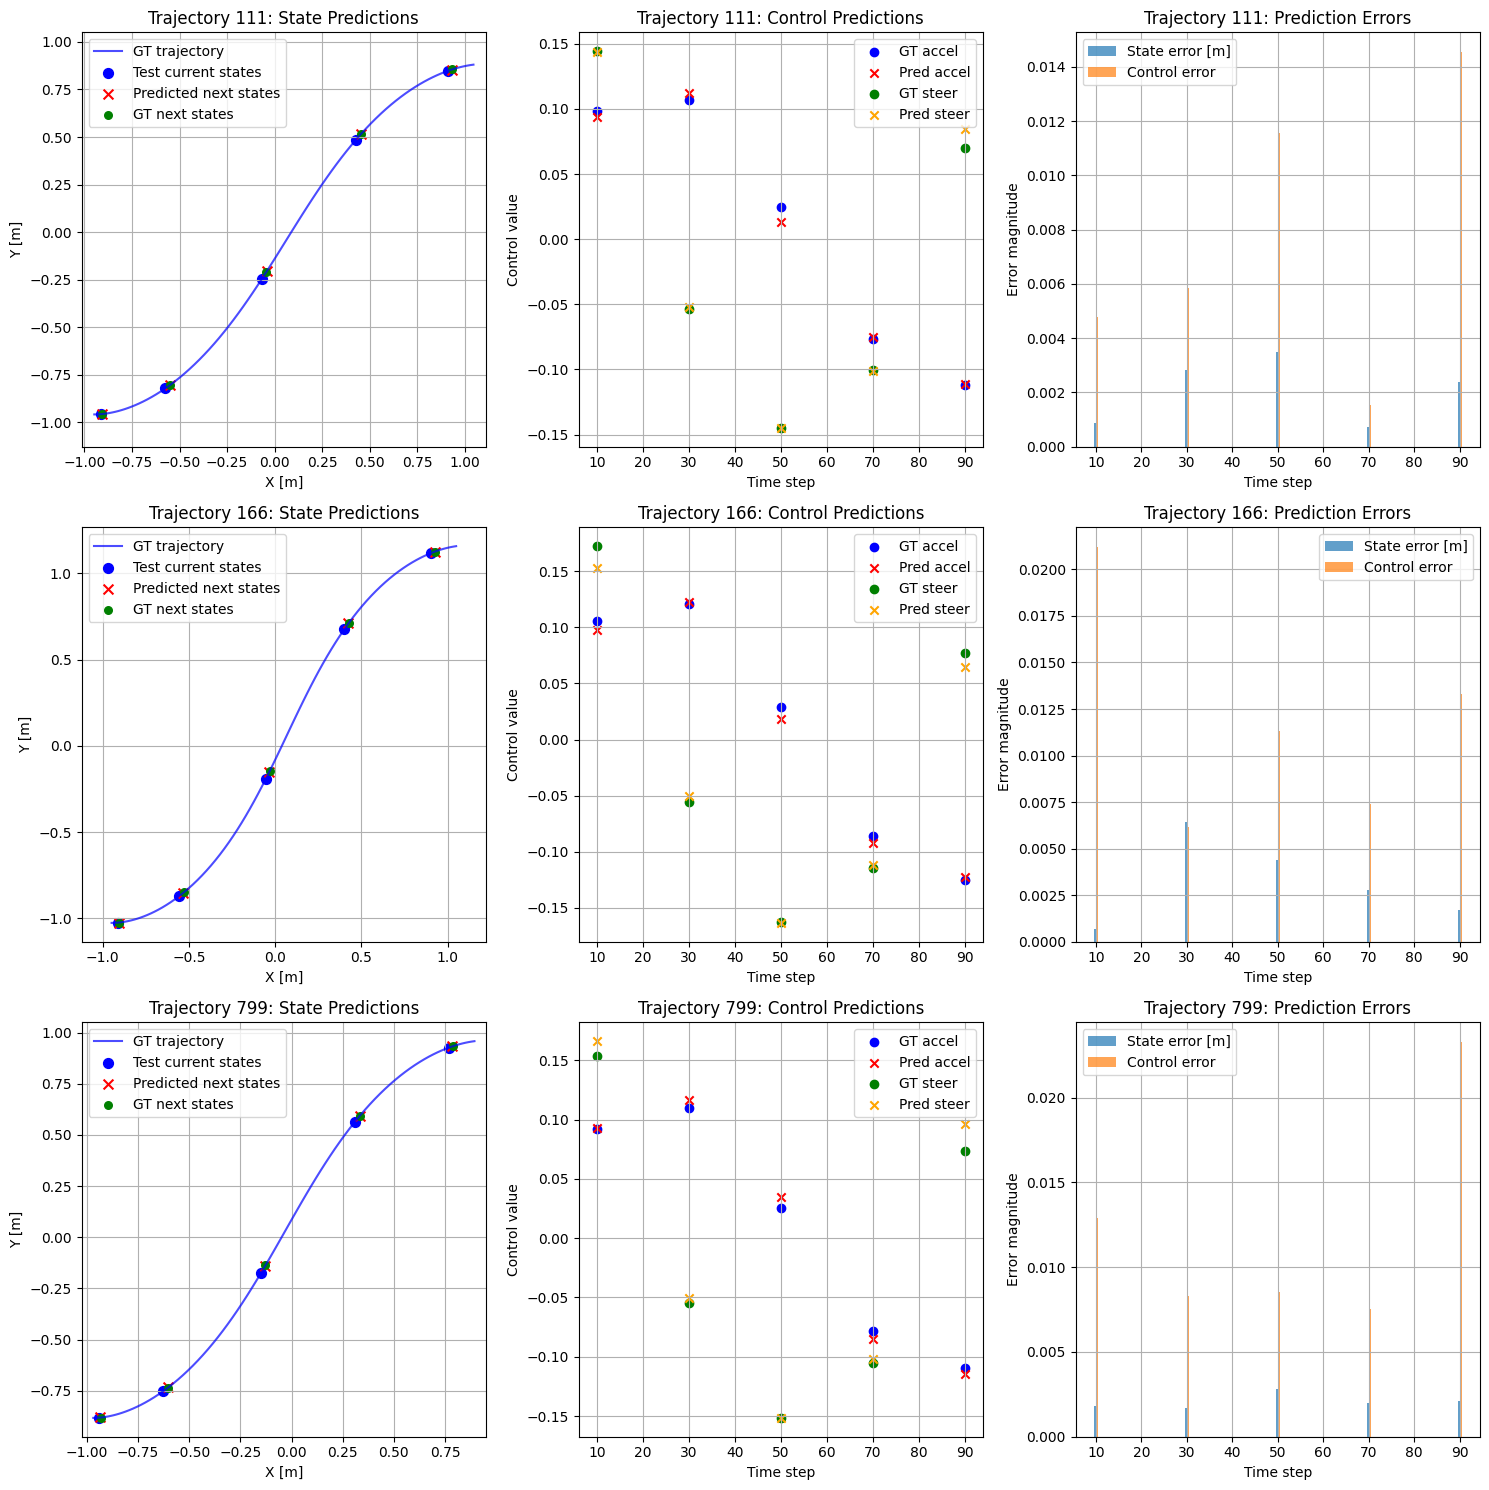


Inference testing completed!


In [14]:
# Cell 10: Test inference on ground truth data
# Load best model
checkpoint = torch.load('single_step_flow_model_best.pt', map_location=device, weights_only=False)
flow_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} with loss {checkpoint['loss']:.6f}")


# Test on a few random trajectories
num_test_trajectories = 3
test_indices = np.random.choice(len(trajectories), num_test_trajectories, replace=False)

fig, axes = plt.subplots(num_test_trajectories, 3, figsize=(15, 5*num_test_trajectories))
if num_test_trajectories == 1:
    axes = axes.reshape(1, -1)

for i, traj_idx in enumerate(test_indices):
    traj = trajectories[traj_idx]
    gt_states = traj['states'][:, :3]  # (100, 3)
    gt_controls = traj['controls'][:100, :]  # (100, 2)
    
    # Test inference at a few random time steps
    test_steps = [10, 30, 50, 70, 90]
    
    pred_controls = []
    pred_next_states = []
    gt_controls_test = []
    gt_next_states_test = []
    
    for step in test_steps:
        if step < 99:  # Normal step
            current_state = gt_states[step]
            gt_control = gt_controls[step]
            gt_next_state = gt_states[step + 1]
        else:  # Last step (special case)
            current_state = gt_states[step]
            gt_control = np.zeros(2)  # Zero control
            gt_next_state = gt_states[step]  # Repeated state
        
        # Predict using flow matching
        pred_control, pred_next_state = single_step_inference(
            current_state, flow_model, state_scaler, control_scaler, device
        )
        
        pred_controls.append(pred_control)
        pred_next_states.append(pred_next_state)
        gt_controls_test.append(gt_control)
        gt_next_states_test.append(gt_next_state)
    
    pred_controls = np.array(pred_controls)
    pred_next_states = np.array(pred_next_states)
    gt_controls_test = np.array(gt_controls_test)
    gt_next_states_test = np.array(gt_next_states_test)
    
    # Plot results
    # Full trajectory
    axes[i, 0].plot(gt_states[:, 0], gt_states[:, 1], 'b-', alpha=0.7, label='GT trajectory')
    axes[i, 0].scatter(gt_states[test_steps, 0], gt_states[test_steps, 1], 
                      c='blue', s=50, label='Test current states')
    axes[i, 0].scatter(pred_next_states[:, 0], pred_next_states[:, 1], 
                      c='red', s=50, marker='x', label='Predicted next states')
    axes[i, 0].scatter(gt_next_states_test[:, 0], gt_next_states_test[:, 1], 
                      c='green', s=30, marker='o', label='GT next states')
    axes[i, 0].set_title(f'Trajectory {traj_idx}: State Predictions')
    axes[i, 0].set_xlabel('X [m]')
    axes[i, 0].set_ylabel('Y [m]')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    axes[i, 0].axis('equal')
    
    # Control comparison
    test_steps_arr = np.array(test_steps)
    axes[i, 1].scatter(test_steps_arr, gt_controls_test[:, 0], c='blue', label='GT accel')
    axes[i, 1].scatter(test_steps_arr, pred_controls[:, 0], c='red', marker='x', label='Pred accel')
    axes[i, 1].scatter(test_steps_arr, gt_controls_test[:, 1], c='green', label='GT steer')
    axes[i, 1].scatter(test_steps_arr, pred_controls[:, 1], c='orange', marker='x', label='Pred steer')
    axes[i, 1].set_title(f'Trajectory {traj_idx}: Control Predictions')
    axes[i, 1].set_xlabel('Time step')
    axes[i, 1].set_ylabel('Control value')
    axes[i, 1].legend()
    axes[i, 1].grid(True)
    
    # Error analysis
    state_errors = np.linalg.norm(pred_next_states - gt_next_states_test, axis=1)
    control_errors = np.linalg.norm(pred_controls - gt_controls_test, axis=1)
    
    axes[i, 2].bar(test_steps_arr - 0.2, state_errors, 0.4, label='State error [m]', alpha=0.7)
    axes[i, 2].bar(test_steps_arr + 0.2, control_errors, 0.4, label='Control error', alpha=0.7)
    axes[i, 2].set_title(f'Trajectory {traj_idx}: Prediction Errors')
    axes[i, 2].set_xlabel('Time step')
    axes[i, 2].set_ylabel('Error magnitude')
    axes[i, 2].legend()
    axes[i, 2].grid(True)
    
    print(f"Trajectory {traj_idx}:")
    print(f"  Mean state error: {state_errors.mean():.4f} m")
    print(f"  Mean control error: {control_errors.mean():.4f}")

plt.tight_layout()
plt.show()

print("\nInference testing completed!")


In [26]:

# Cell: Full 100-Step Rollout Generation
def full_trajectory_rollout(flow_model, state_scaler, control_scaler, device, 
                           num_rollouts=5, trajectory_length=100, dataset=None):
    """
    完整的100步轨迹rollout生成
    
    Args:
        flow_model: 训练好的Flow Matching模型
        state_scaler, control_scaler: 数据标准化器
        device: 计算设备
        num_rollouts: 生成的轨迹数量
        trajectory_length: 轨迹长度
        dataset: 训练数据集（用于获取起始点）
    
    Returns:
        generated_trajectories: 生成的轨迹列表
        initial_states: 对应的初始状态
    """
    flow_model.eval()
    
    if dataset is None:
        # 如果没有提供数据集，使用随机初始状态
        print("Warning: No dataset provided, using random initial states")
        initial_states = []
        init_state_index = []  # 空列表，因为没有对应的轨迹索引
        for _ in range(num_rollouts):
            # 随机生成初始状态 [x, y, theta] 在合理范围内
            init_state = np.array([
                np.random.uniform(-1.0, 1.0),  # x
                np.random.uniform(-1.0, 1.0),  # y  
                np.random.uniform(0, 2*np.pi)  # theta
            ])
            initial_states.append(init_state)
    else:
        # 从数据集中随机选择起始点
        initial_states = []
        init_state_index = []
        for _ in range(num_rollouts):
            # 随机选择一个轨迹的起始点
            traj_idx = np.random.randint(0, len(trajectories))
            init_state = trajectories[traj_idx]['states'][0, :3]  # [x, y, theta]
            initial_states.append(init_state)
            init_state_index.append(traj_idx)
            print(f"Selected initial state from trajectory {traj_idx}: {init_state}")
           
    
    generated_trajectories = []
    
    # ODE求解函数
    def ode_func(t, x_flat):
        """ODE函数用于Flow Matching推理"""
        x = x_flat.view(1, 5)
        t_tensor = torch.tensor([t], device=device, dtype=torch.float32)
        
        with torch.no_grad():
            velocity = flow_model(x, t_tensor, condition=current_condition_tensor)
        
        return velocity.view(-1)
    
    print(f"\nGenerating {num_rollouts} full rollout trajectories...")
    print("=" * 60)
    
    for rollout_idx in range(num_rollouts):
        print(f"\nRollout {rollout_idx + 1}/{num_rollouts}")
        
        # 初始状态
        current_state = initial_states[rollout_idx].copy()  # [x, y, theta]
        
        # 存储生成的轨迹
        rollout_states = [current_state.copy()]
        rollout_controls = []
        
        print(f"Initial state: [{current_state[0]:.4f}, {current_state[1]:.4f}, {current_state[2]:.4f}]")
        
        # 逐步生成100步
        for step in range(trajectory_length):
            # 1. 标准化当前状态作为条件
            current_state_norm = state_scaler.normalize(current_state)
            current_condition_tensor = torch.from_numpy(
                current_state_norm.astype(np.float32)
            ).unsqueeze(0).to(device)  # (1, 3)
            
            # 2. 初始噪声
            x0 = torch.randn(1, 5, device=device)
            
            # 3. 使用ODE求解进行Flow Matching推理
            try:
                with torch.no_grad():
                    t_span = torch.tensor([0., 1.], device=device)
                    result = torchdiffeq.odeint(
                        ode_func,
                        x0.view(-1),
                        t_span,
                        atol=1e-5,
                        rtol=1e-5,
                        method='dopri5'
                    )
                    
                    # 获取最终结果
                    final_result = result[-1].view(5).cpu().numpy()  # (5,)
                    
            except Exception as e:
                print(f"ODE solving failed at step {step}: {e}")
                print("Using backup single-step prediction...")
                
                # 备用方案：直接使用模型预测
                with torch.no_grad():
                    # 使用固定时间点 t=1 进行预测
                    t_tensor = torch.ones(1, device=device)
                    x_input = torch.randn(1, 5, device=device)
                    
                    pred_output = flow_model(x_input, t_tensor, condition=current_condition_tensor)
                    final_result = pred_output.cpu().numpy()[0]
            
            # 4. 拆分预测结果
            predicted_control_norm = final_result[:2]  # 控制量 [accel, steer]
            predicted_next_state_norm = final_result[2:]  # 下一状态 [x, y, theta]
            
            # 5. 反标准化
            predicted_control = control_scaler.denormalize(predicted_control_norm)
            predicted_next_state = state_scaler.denormalize(predicted_next_state_norm)
            
            # 6. 存储结果
            rollout_controls.append(predicted_control)
            rollout_states.append(predicted_next_state)
            
            # 7. 更新当前状态（关键：用预测的下一状态作为下一步的条件）
            current_state = predicted_next_state.copy()
            
            # 8. 进度显示
            if (step + 1) % 20 == 0:
                print(f"  Step {step + 1:3d}: State=[{current_state[0]:.3f}, {current_state[1]:.3f}, {current_state[2]:.3f}], "
                      f"Control=[{predicted_control[0]:.3f}, {predicted_control[1]:.3f}]")
        
        # 转换为numpy数组
        rollout_states = np.array(rollout_states)  # (101, 3)
        rollout_controls = np.array(rollout_controls)  # (100, 2)
        
        # 存储完整轨迹
        generated_trajectory = {
            'states': rollout_states,
            'controls': rollout_controls,
            'initial_state': initial_states[rollout_idx]
        }
        generated_trajectories.append(generated_trajectory)
        
        print(f"  ✅ Rollout {rollout_idx + 1} completed: {len(rollout_states)} states, {len(rollout_controls)} controls")
        print(f"  Final state: [{current_state[0]:.4f}, {current_state[1]:.4f}, {current_state[2]:.4f}]")
    
    return generated_trajectories, initial_states, init_state_index

# 执行完整rollout生成
print("🚀 Starting Full Trajectory Rollout Generation...")
generated_trajectories, initial_states, init_state_index = full_trajectory_rollout(
    flow_model=flow_model,
    state_scaler=state_scaler, 
    control_scaler=control_scaler,
    device=device,
    num_rollouts=3,  # 生成3条轨迹
    trajectory_length=100,
    dataset=trajectories  # 使用现有数据集的起始点
)

print(f"\n🎉 Generated {len(generated_trajectories)} complete rollout trajectories!")

🚀 Starting Full Trajectory Rollout Generation...
Selected initial state from trajectory 362: [-1.02773887 -1.02399342  0.        ]
Selected initial state from trajectory 805: [-0.92797121 -0.9448401   0.        ]
Selected initial state from trajectory 631: [-1.02631958 -0.97489579  0.        ]

Generating 3 full rollout trajectories...

Rollout 1/3
Initial state: [-1.0277, -1.0240, 0.0000]
  Step  20: State=[-0.846, -0.989, 0.369], Control=[0.115, 0.035]
  Step  40: State=[-0.349, -0.585, 0.917], Control=[0.092, -0.115]
  Step  60: State=[0.130, 0.218, 1.046], Control=[-0.035, -0.148]
  Step  80: State=[0.637, 0.874, 0.644], Control=[-0.118, -0.039]
  Step 100: State=[1.006, 1.041, 0.126], Control=[0.000, -0.000]
  ✅ Rollout 1 completed: 101 states, 100 controls
  Final state: [1.0058, 1.0413, 0.1262]

Rollout 2/3
Initial state: [-0.9280, -0.9448, 0.0000]
  Step  20: State=[-0.755, -0.916, 0.360], Control=[0.123, 0.046]
  Step  40: State=[-0.287, -0.540, 0.921], Control=[0.089, -0.117]

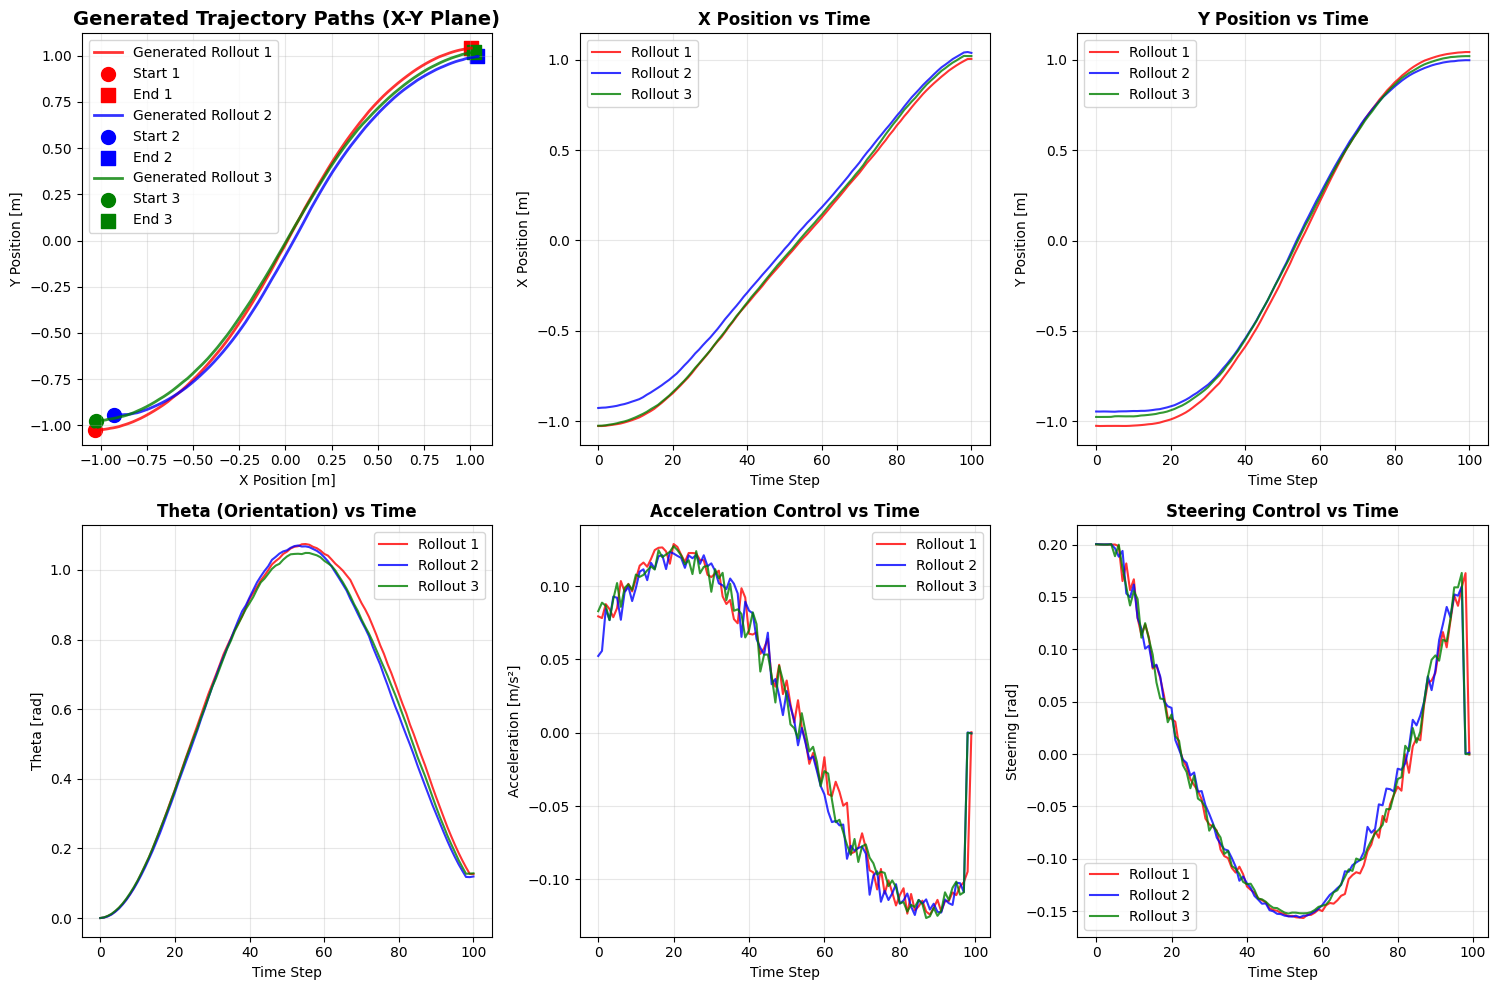


📊 Rollout Trajectory Statistics:
Rollout 1:
  Path length: 3.016 m
  Position range: X=[-1.028, 1.006], Y=[-1.025, 1.041]
  Max controls: Accel=0.129, Steer=0.200
  Final position: [1.006, 1.041, 0.126]

Rollout 2:
  Path length: 2.889 m
  Position range: X=[-0.928, 1.044], Y=[-0.946, 0.996]
  Max controls: Accel=0.124, Steer=0.200
  Final position: [1.039, 0.996, 0.119]

Rollout 3:
  Path length: 2.969 m
  Position range: X=[-1.026, 1.022], Y=[-0.975, 1.019]
  Max controls: Accel=0.127, Steer=0.200
  Final position: [1.021, 1.019, 0.128]



In [27]:
# Cell: Visualize Generated Rollout Trajectories
def visualize_rollout_trajectories(generated_trajectories, original_trajectories=None, figsize=(15, 10)):
    """
    可视化生成的rollout轨迹
    
    Args:
        generated_trajectories: 生成的轨迹列表
        original_trajectories: 原始数据集轨迹（可选，用于对比）
        figsize: 图形大小
    """
    num_rollouts = len(generated_trajectories)
    
    # 创建子图
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    # 颜色映射
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']  # (101, 3)
        controls = traj['controls']  # (100, 2)
        
        # 1. 轨迹路径 (x-y平面)
        axes[0].plot(states[:, 0], states[:, 1], 
                    color=colors[i % len(colors)], 
                    linewidth=2, 
                    label=f'Generated Rollout {i+1}',
                    alpha=0.8)
        axes[0].scatter(states[0, 0], states[0, 1], 
                       color=colors[i % len(colors)], 
                       s=100, marker='o', label=f'Start {i+1}')
        axes[0].scatter(states[-1, 0], states[-1, 1], 
                       color=colors[i % len(colors)], 
                       s=100, marker='s', label=f'End {i+1}')
    
    axes[0].set_title('Generated Trajectory Paths (X-Y Plane)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X Position [m]')
    axes[0].set_ylabel('Y Position [m]') 
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('equal')
    
    # 2. 状态时间序列
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']
        time_steps = np.arange(len(states))
        
        # X位置
        axes[1].plot(time_steps, states[:, 0], 
                    color=colors[i % len(colors)], 
                    label=f'Rollout {i+1}', alpha=0.8)
    axes[1].set_title('X Position vs Time', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('X Position [m]')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Y位置时间序列
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']
        time_steps = np.arange(len(states))
        
        axes[2].plot(time_steps, states[:, 1], 
                    color=colors[i % len(colors)], 
                    label=f'Rollout {i+1}', alpha=0.8)
    axes[2].set_title('Y Position vs Time', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Time Step')
    axes[2].set_ylabel('Y Position [m]')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # 4. 角度时间序列
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']
        time_steps = np.arange(len(states))
        
        axes[3].plot(time_steps, states[:, 2], 
                    color=colors[i % len(colors)], 
                    label=f'Rollout {i+1}', alpha=0.8)
    axes[3].set_title('Theta (Orientation) vs Time', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Time Step')
    axes[3].set_ylabel('Theta [rad]')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # 5. 控制输入：加速度
    for i, traj in enumerate(generated_trajectories):
        controls = traj['controls']
        time_steps = np.arange(len(controls))
        
        axes[4].plot(time_steps, controls[:, 0], 
                    color=colors[i % len(colors)], 
                    label=f'Rollout {i+1}', alpha=0.8)
    axes[4].set_title('Acceleration Control vs Time', fontsize=12, fontweight='bold')
    axes[4].set_xlabel('Time Step')
    axes[4].set_ylabel('Acceleration [m/s²]')
    axes[4].legend()
    axes[4].grid(True, alpha=0.3)
    
    # 6. 控制输入：转向
    for i, traj in enumerate(generated_trajectories):
        controls = traj['controls']
        time_steps = np.arange(len(controls))
        
        axes[5].plot(time_steps, controls[:, 1], 
                    color=colors[i % len(colors)], 
                    label=f'Rollout {i+1}', alpha=0.8)
    axes[5].set_title('Steering Control vs Time', fontsize=12, fontweight='bold')
    axes[5].set_xlabel('Time Step')
    axes[5].set_ylabel('Steering [rad]')
    axes[5].legend()
    axes[5].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印轨迹统计信息
    print("\n📊 Rollout Trajectory Statistics:")
    print("=" * 50)
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']
        controls = traj['controls']
        
        # 计算轨迹长度
        path_length = np.sum(np.sqrt(np.diff(states[:, 0])**2 + np.diff(states[:, 1])**2))
        
        # 控制统计
        max_accel = np.max(np.abs(controls[:, 0]))
        max_steer = np.max(np.abs(controls[:, 1]))
        
        print(f"Rollout {i+1}:")
        print(f"  Path length: {path_length:.3f} m")
        print(f"  Position range: X=[{states[:, 0].min():.3f}, {states[:, 0].max():.3f}], "
              f"Y=[{states[:, 1].min():.3f}, {states[:, 1].max():.3f}]")
        print(f"  Max controls: Accel={max_accel:.3f}, Steer={max_steer:.3f}")
        print(f"  Final position: [{states[-1, 0]:.3f}, {states[-1, 1]:.3f}, {states[-1, 2]:.3f}]")
        print()

# 可视化生成的轨迹
visualize_rollout_trajectories(generated_trajectories)

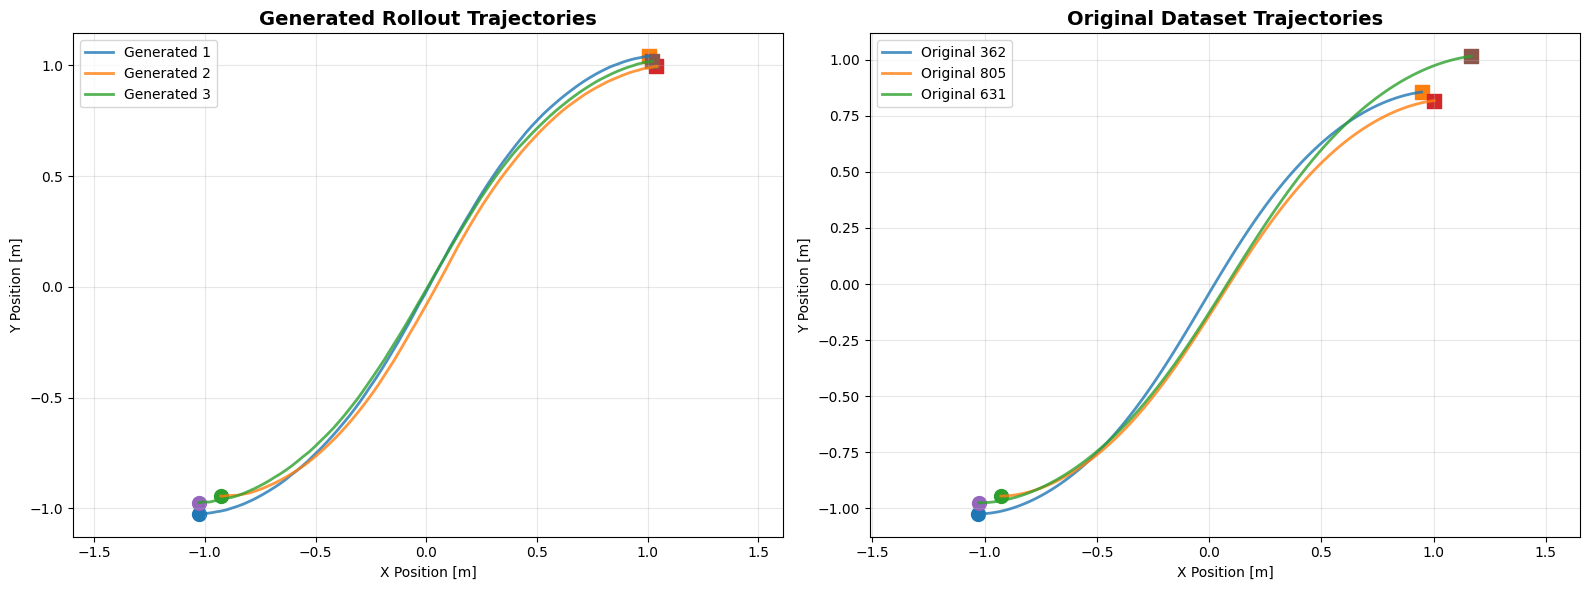

📈 Trajectory Comparison Analysis:
Generated trajectories - Average path length: 2.958 ± 0.053 m
Original trajectories - Average path length: 2.868 ± 0.152 m


In [28]:
# Cell: Compare with Original Dataset Trajectories
def compare_with_original_trajectories(generated_trajectories, original_trajectories, init_state_index, num_compare=3):
    """
    将生成的轨迹与原始数据集轨迹进行对比
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 使用指定的轨迹索引进行对比
    original_indices = init_state_index

    # 左图：生成的轨迹
    for i, traj in enumerate(generated_trajectories):
        states = traj['states']
        axes[0].plot(states[:, 0], states[:, 1], 
                    linewidth=2, label=f'Generated {i+1}', alpha=0.8)
        axes[0].scatter(states[0, 0], states[0, 1], s=100, marker='o')
        axes[0].scatter(states[-1, 0], states[-1, 1], s=100, marker='s')
    
    axes[0].set_title('Generated Rollout Trajectories', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X Position [m]')
    axes[0].set_ylabel('Y Position [m]')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('equal')
    # 右图：原始轨迹对比
    for i, idx in enumerate(original_indices):
        traj = original_trajectories[idx]
        states = traj['states'][:, :3]  # 只取前3维
        axes[1].plot(states[:, 0], states[:, 1], 
                    linewidth=2, label=f'Original {idx}', alpha=0.8)
        axes[1].scatter(states[0, 0], states[0, 1], s=100, marker='o')
        axes[1].scatter(states[-1, 0], states[-1, 1], s=100, marker='s')
    
    axes[1].set_title('Original Dataset Trajectories', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('X Position [m]')
    axes[1].set_ylabel('Y Position [m]')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("📈 Trajectory Comparison Analysis:")
    print("=" * 40)
    
    # 分析生成轨迹的特性
    gen_path_lengths = []
    for traj in generated_trajectories:
        states = traj['states']
        path_length = np.sum(np.sqrt(np.diff(states[:, 0])**2 + np.diff(states[:, 1])**2))
        gen_path_lengths.append(path_length)
    
    # 分析原始轨迹的特性
    orig_path_lengths = []
    for idx in original_indices:
        states = original_trajectories[idx]['states'][:, :3]
        path_length = np.sum(np.sqrt(np.diff(states[:, 0])**2 + np.diff(states[:, 1])**2))
        orig_path_lengths.append(path_length)
    
    print(f"Generated trajectories - Average path length: {np.mean(gen_path_lengths):.3f} ± {np.std(gen_path_lengths):.3f} m")
    print(f"Original trajectories - Average path length: {np.mean(orig_path_lengths):.3f} ± {np.std(orig_path_lengths):.3f} m")
    
    return gen_path_lengths, orig_path_lengths

# 执行对比分析
gen_lengths, orig_lengths = compare_with_original_trajectories(
    generated_trajectories, trajectories, init_state_index, num_compare=3
)

In [1]:
# Full rollout test using flow model with real vehicle dynamics
def full_rollout_with_dynamics(flow_model, initial_state, num_steps, dt=0.1, device='cuda'):
    """
    Perform a full dynamic rollout using the flow model, considering real vehicle dynamics.
    
    Args:
        flow_model: Trained flow model
        initial_state: Initial state [x, y, theta, v, r] (numpy array)
        num_steps: Number of rollout steps
        dt: Time step
        device: Computation device
    
    Returns:
        states: Sequence of real states (num_steps+1, 5)
        predicted_states: Sequence of model-predicted states (num_steps+1, 5)
        controls: Sequence of controls (num_steps, 2)
    """
    # Initialization
    states = np.zeros((num_steps + 1, 5))
    predicted_states = np.zeros((num_steps + 1, 5))
    controls = np.zeros((num_steps, 2))
    
    # Set initial state
    states[0] = initial_state
    predicted_states[0] = initial_state
    
    print(f"🚗 Starting dynamic rollout, initial state: {initial_state}")
    print("=" * 60)
    
    for step in range(num_steps):
        # Use current real state as condition
        current_real_state = states[step]
        
        # Convert state to tensor (use first 4 dimensions as condition)
        state_tensor = torch.tensor(current_real_state[:4], dtype=torch.float32).unsqueeze(0).to(device)
        
        # Generate control using flow model
        with torch.no_grad():
            # Sample noise from standard normal distribution
            noise = torch.randn(1, 2).to(device)
            # Generate control using flow model (reverse process)
            generated_control = flow_model.reverse(noise, state_tensor)
            control = generated_control.cpu().numpy().flatten()
        
        # Apply control constraints
        control[0] = np.clip(control[0], -0.25, 0.25)  # Acceleration constraint
        control[1] = np.clip(control[1], -0.2, 0.2)    # Steering angle constraint
        
        controls[step] = control
        
        # Compute next state using real vehicle dynamics
        x, y, theta, v, r = current_real_state
        a, delta = control
        
        # Vehicle dynamics equations (Euler integration)
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        
        # Update real state
        next_real_state = np.array([x_next, y_next, theta_next, v_next, r_next])
        states[step + 1] = next_real_state
        
        # Also record model-predicted next state (for comparison)
        # Model prediction: current state + generated control -> predicted next state
        predicted_next_state = current_real_state.copy()
        predicted_next_state[0] += dt * current_real_state[3] * np.cos(current_real_state[2])
        predicted_next_state[1] += dt * current_real_state[3] * np.sin(current_real_state[2])
        predicted_next_state[2] += dt * current_real_state[4]
        predicted_next_state[3] += dt * control[0]
        predicted_next_state[4] += dt * control[1]
        predicted_states[step + 1] = predicted_next_state
        
        # Print step info
        if step % 10 == 0 or step < 5:
            print(f"Step {step:2d}: control=[{control[0]:6.3f}, {control[1]:6.3f}] "
                  f"state=[{x_next:6.2f}, {y_next:6.2f}, {theta_next:6.3f}, {v_next:6.3f}, {r_next:6.3f}]")
    
    print("=" * 60)
    print("✅ Dynamic rollout finished!")
    
    return states, predicted_states, controls

# Test full dynamic rollout
print("🔄 Testing full dynamic rollout...")

# Choose an initial state
test_initial_state = np.array([0.0, 0.0, 0.0, 1.0, 0.0])  # [x, y, theta, v, r]
rollout_steps = 50

# Perform rollout
real_states, pred_states, generated_controls = full_rollout_with_dynamics(
    flow_model, test_initial_state, rollout_steps, dt=0.1, device=device
)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Trajectory comparison
axes[0, 0].plot(real_states[:, 0], real_states[:, 1], 'b-', linewidth=3, label='Real Trajectory', alpha=0.8)
axes[0, 0].plot(pred_states[:, 0], pred_states[:, 1], 'r--', linewidth=2, label='Predicted Trajectory', alpha=0.8)
axes[0, 0].scatter(real_states[0, 0], real_states[0, 1], s=150, c='green', marker='o', label='Start', zorder=5)
axes[0, 0].scatter(real_states[-1, 0], real_states[-1, 1], s=150, c='red', marker='s', label='End', zorder=5)
axes[0, 0].set_title('Trajectory Comparison (Real vs Predicted)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('X Position [m]')
axes[0, 0].set_ylabel('Y Position [m]')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axis('equal')

# Control input time series
time_steps = np.arange(rollout_steps) * 0.1
axes[0, 1].plot(time_steps, generated_controls[:, 0], 'b-', linewidth=2, label='Acceleration [m/s²]')
axes[0, 1].axhline(y=0.25, color='r', linestyle='--', alpha=0.7, label='Acceleration Upper Bound')
axes[0, 1].axhline(y=-0.25, color='r', linestyle='--', alpha=0.7, label='Acceleration Lower Bound')
axes[0, 1].set_title('Generated Control Input - Acceleration', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time [s]')
axes[0, 1].set_ylabel('Acceleration [m/s²]')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(time_steps, generated_controls[:, 1], 'g-', linewidth=2, label='Steering Angle [rad]')
axes[1, 0].axhline(y=0.2, color='r', linestyle='--', alpha=0.7, label='Steering Angle Upper Bound')
axes[1, 0].axhline(y=-0.2, color='r', linestyle='--', alpha=0.7, label='Steering Angle Lower Bound')
axes[1, 0].set_title('Generated Control Input - Steering Angle', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time [s]')
axes[1, 0].set_ylabel('Steering Angle [rad]')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# State evolution
time_points = np.arange(rollout_steps + 1) * 0.1
axes[1, 1].plot(time_points, real_states[:, 3], 'b-', linewidth=2, label='Velocity [m/s]')
axes[1, 1].plot(time_points, real_states[:, 4], 'r-', linewidth=2, label='Angular Velocity [rad/s]')
axes[1, 1].set_title('State Evolution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time [s]')
axes[1, 1].set_ylabel('Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis results
print("\n📊 Rollout Analysis Results:")
print("=" * 40)
print(f"Total path length: {np.sum(np.sqrt(np.diff(real_states[:, 0])**2 + np.diff(real_states[:, 1])**2)):.3f} m")
print(f"Final position: ({real_states[-1, 0]:.3f}, {real_states[-1, 1]:.3f})")
print(f"Final velocity: {real_states[-1, 3]:.3f} m/s")
print(f"Final angular velocity: {real_states[-1, 4]:.3f} rad/s")
print(f"Mean acceleration: {np.mean(np.abs(generated_controls[:, 0])):.3f} m/s²")
print(f"Mean steering angle: {np.mean(np.abs(generated_controls[:, 1])):.3f} rad")

# Compute error between real and predicted trajectories
position_error = np.sqrt(np.sum((real_states[:, :2] - pred_states[:, :2])**2, axis=1))
print(f"Mean position error: {np.mean(position_error):.4f} m")
print(f"Max position error: {np.max(position_error):.4f} m")


🔄 Testing full dynamic rollout...


NameError: name 'np' is not defined

In [2]:
# 保存模型权重
torch.save(flow_model.state_dict(), 'car_fm_model_policy_weights.pth')
print("✅ 模型权重已保存到 'car_fm_model_weights.pth'")

# 加载模型权重
flow_model.load_state_dict(torch.load('car_fm_model_policy_weights.pth'))
print("✅ 模型权重已加载")

# 测试加载后的模型
test_state = torch.tensor([0.0, 0.0, 0.0, 0.0], dtype=torch.float32).unsqueeze(0).to(device)
test_control = torch.tensor([0.0, 0.0], dtype=torch.float32).unsqueeze(0).to(device)


NameError: name 'torch' is not defined